In [23]:
library(tidyverse)
library(caret)
library(rpart)
library(rpart.plot)
library(randomForest)
library(glmnet)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-8



# Unit 1

1.

In [3]:
data <- read_csv("/kaggle/input/datasets/ivancobarrubias/customer-churn/customer_churn.csv")

Rows: 10000 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (8): CustomerID, Gender, Partner, Dependents, PhoneService, InternetServ...
dbl (4): SeniorCitizen, Tenure, MonthlyCharges, TotalCharges

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
head(data)

CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
CUST00001,Male,0,No,No,65,Yes,Fiber optic,Month-to-month,20.04,1302.60,No
CUST00002,Male,0,No,No,26,Yes,Fiber optic,Month-to-month,65.14,1693.64,No
CUST00003,Male,0,Yes,No,54,Yes,Fiber optic,Month-to-month,49.38,2666.52,No
CUST00004,Female,0,Yes,Yes,70,Yes,DSL,One year,31.19,2183.30,No
CUST00005,Male,0,No,No,53,Yes,DSL,Month-to-month,103.86,5504.58,Yes
CUST00006,Female,0,No,Yes,45,Yes,Fiber optic,Month-to-month,87.34,3930.30,Yes


In [5]:
str(data)
dim(data)
summary(data)

spc_tbl_ [10,000 × 12] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ CustomerID     : chr [1:10000] "CUST00001" "CUST00002" "CUST00003" "CUST00004" ...
 $ Gender         : chr [1:10000] "Male" "Male" "Male" "Female" ...
 $ SeniorCitizen  : num [1:10000] 0 0 0 0 0 0 0 0 0 0 ...
 $ Partner        : chr [1:10000] "No" "No" "Yes" "Yes" ...
 $ Dependents     : chr [1:10000] "No" "No" "No" "Yes" ...
 $ Tenure         : num [1:10000] 65 26 54 70 53 45 35 20 48 33 ...
 $ PhoneService   : chr [1:10000] "Yes" "Yes" "Yes" "Yes" ...
 $ InternetService: chr [1:10000] "Fiber optic" "Fiber optic" "Fiber optic" "DSL" ...
 $ Contract       : chr [1:10000] "Month-to-month" "Month-to-month" "Month-to-month" "One year" ...
 $ MonthlyCharges : num [1:10000] 20 65.1 49.4 31.2 103.9 ...
 $ TotalCharges   : num [1:10000] 1303 1694 2667 2183 5505 ...
 $ Churn          : chr [1:10000] "No" "No" "No" "No" ...
 - attr(*, "spec")=
  .. cols(
  ..   CustomerID = col_character(),
  ..   Gender = col_character(),
  ..  

[1] 10000    12

  CustomerID           Gender          SeniorCitizen      Partner         
 Length:10000       Length:10000       Min.   :0.0000   Length:10000      
 Class :character   Class :character   1st Qu.:0.0000   Class :character  
 Mode  :character   Mode  :character   Median :0.0000   Mode  :character  
                                       Mean   :0.1502                     
                                       3rd Qu.:0.0000                     
                                       Max.   :1.0000                     
  Dependents            Tenure      PhoneService       InternetService   
 Length:10000       Min.   : 0.00   Length:10000       Length:10000      
 Class :character   1st Qu.:17.00   Class :character   Class :character  
 Mode  :character   Median :35.00   Mode  :character   Mode  :character  
                    Mean   :35.22                                        
                    3rd Qu.:53.00                                        
                    Max.   :71.

In [6]:
colSums(is.na(data))

CustomerID          Gender   SeniorCitizen         Partner      Dependents 
              0               0               0               0               0 
         Tenure    PhoneService InternetService        Contract  MonthlyCharges 
              0               0               0               0               0 
   TotalCharges           Churn 
              0               0

Given that customer retention makes more sense economically than customer acquisition, data mining allows companies to act proactively and detect potential customer loss rather than after the fact.

2.

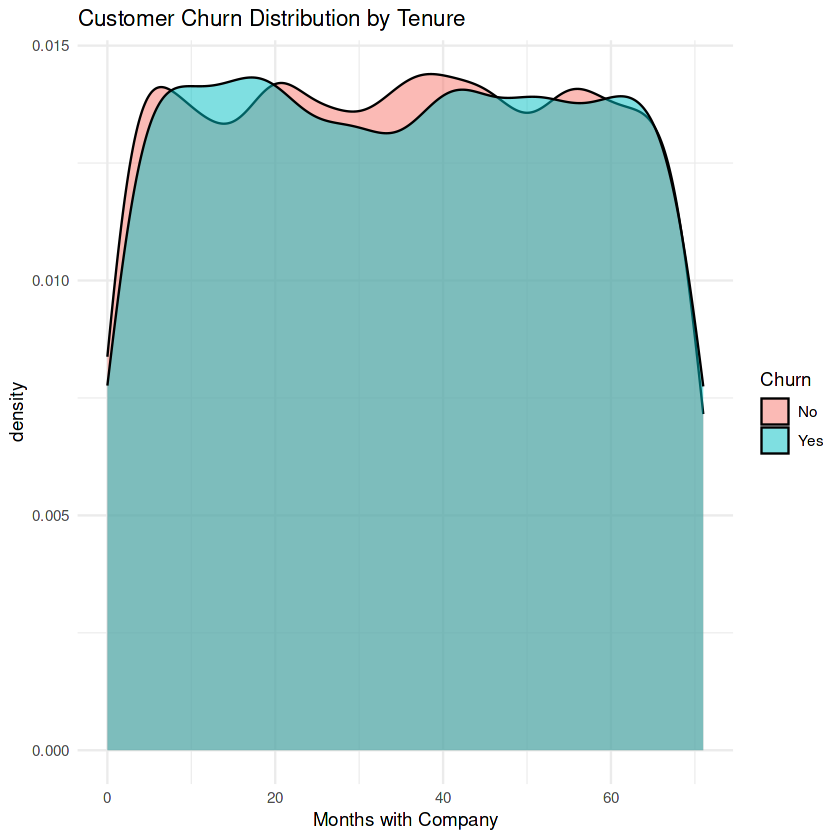

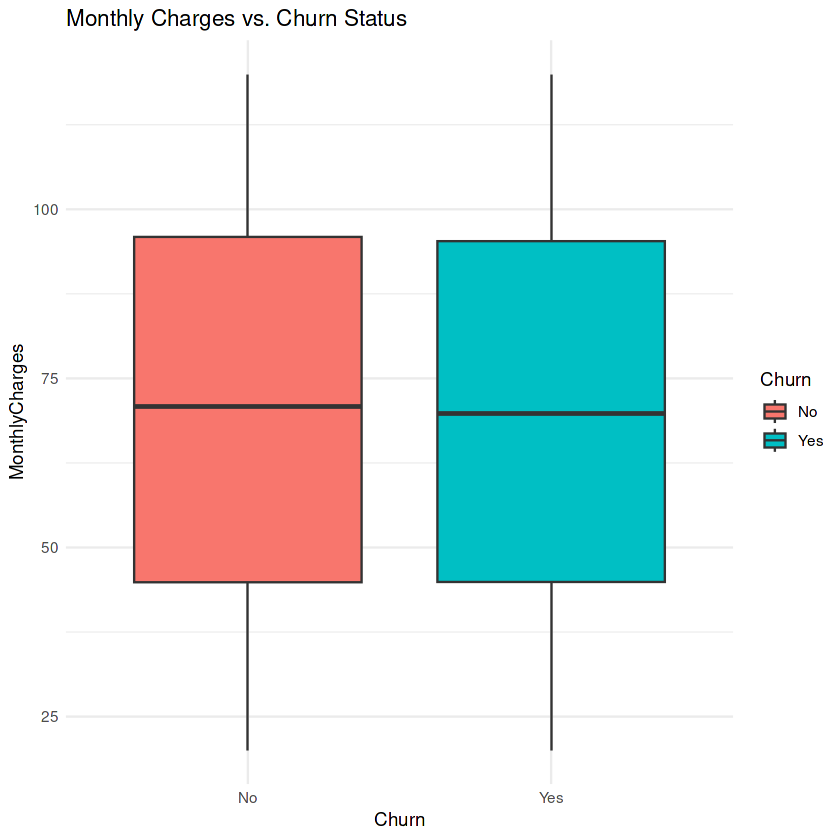

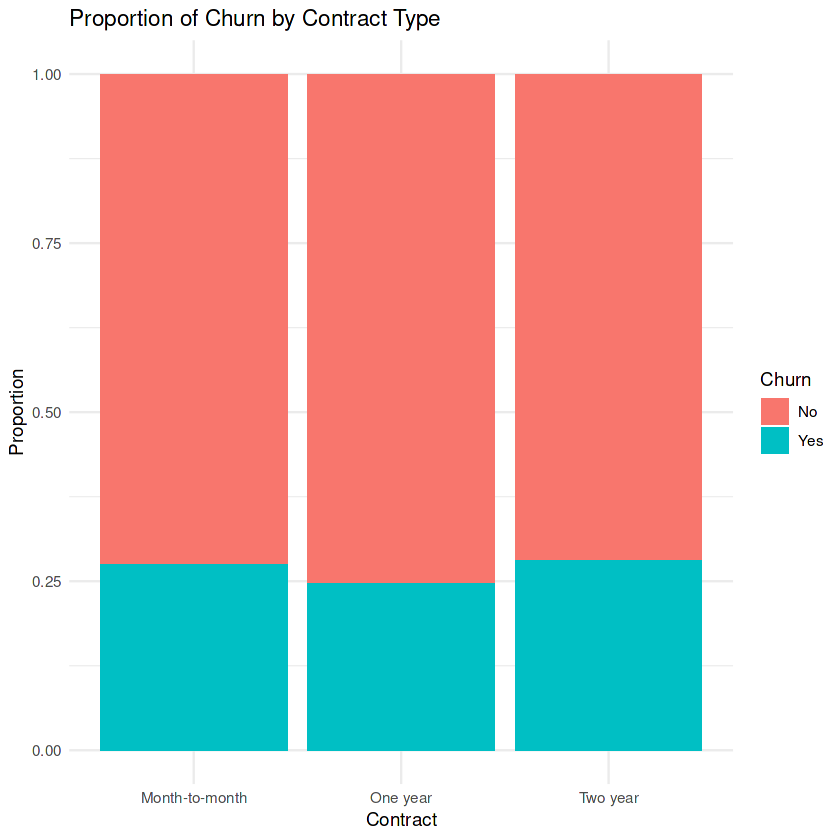

In [7]:
# Plot 1: Churn Rate by Tenure (Density Plot)
ggplot(data, aes(x = Tenure, fill = Churn)) +
  geom_density(alpha = 0.5) +
  labs(title = "Customer Churn Distribution by Tenure", x = "Months with Company") +
  theme_minimal()

# Plot 2: Churn by Monthly Charges (Boxplot)
ggplot(data, aes(x = Churn, y = MonthlyCharges, fill = Churn)) +
  geom_boxplot() +
  labs(title = "Monthly Charges vs. Churn Status") +
  theme_minimal()

# Plot 3: Churn by Contract Type 
ggplot(data, aes(x = Contract, fill = Churn)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion of Churn by Contract Type", y = "Proportion") +
  theme_minimal()

3.

In [8]:
data <- data %>% drop_na(TotalCharges)

cols_to_factor <- c("Gender", "Partner", "Dependents", "Contract", "Churn")
data[cols_to_factor] <- lapply(data[cols_to_factor], as.factor)

data$Tenure_scaled <- scale(data$Tenure)
data$MonthlyCharges_scaled <- scale(data$MonthlyCharges)
data$TotalCharges_scaled <- scale(data$TotalCharges)

In [9]:
glimpse(data)

Rows: 10,000
Columns: 15
$ CustomerID            <chr> "CUST00001", "CUST00002", "CUST00003", "CUST0000…
$ Gender                <fct> Male, Male, Male, Female, Male, Female, Female, …
$ SeniorCitizen         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, …
$ Partner               <fct> No, No, Yes, Yes, No, No, Yes, Yes, Yes, No, No,…
$ Dependents            <fct> No, No, No, Yes, No, Yes, No, Yes, Yes, No, No, …
$ Tenure                <dbl> 65, 26, 54, 70, 53, 45, 35, 20, 48, 33, 33, 39, …
$ PhoneService          <chr> "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes",…
$ InternetService       <chr> "Fiber optic", "Fiber optic", "Fiber optic", "DS…
$ Contract              <fct> Month-to-month, Month-to-month, Month-to-month, …
$ MonthlyCharges        <dbl> 20.04, 65.14, 49.38, 31.19, 103.86, 87.34, 119.9…
$ TotalCharges          <dbl> 1302.60, 1693.64, 2666.52, 2183.30, 5504.58, 393…
$ Churn                 <fct> No, No, No, No, Yes, Yes, Yes, Yes, No, No, Yes,…
$ Tenure_scaled

4.

In [10]:
head(data)

CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn,Tenure_scaled,MonthlyCharges_scaled,TotalCharges_scaled
<chr>,<fct>,<dbl>,<fct>,<fct>,<dbl>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<fct>,"<dbl[,1]>","<dbl[,1]>","<dbl[,1]>"
CUST00001,Male,0,No,No,65,Yes,Fiber optic,Month-to-month,20.04,1302.60,No,1.4325824,-1.7273002,-0.6218138
CUST00002,Male,0,No,No,26,Yes,Fiber optic,Month-to-month,65.14,1693.64,No,-0.4435707,-0.1736089,-0.4109640
CUST00003,Male,0,Yes,No,54,Yes,Fiber optic,Month-to-month,49.38,2666.52,No,0.9034110,-0.7165396,0.1136155
CUST00004,Female,0,Yes,Yes,70,Yes,DSL,One year,31.19,2183.30,No,1.6731149,-1.3431836,-0.1469380
CUST00005,Male,0,No,No,53,Yes,DSL,Month-to-month,103.86,5504.58,Yes,0.8553045,1.1602920,1.6439049
CUST00006,Female,0,No,Yes,45,Yes,Fiber optic,Month-to-month,87.34,3930.30,Yes,0.4704526,0.5911793,0.7950490


In [11]:
cutoff <- quantile(data$MonthlyCharges, 0.99)
data_clean <- data %>% filter(MonthlyCharges <= cutoff)

data_clean <- data_clean %>%
  mutate(AvgChargePerMonth = TotalCharges / (Tenure + 0.001))

churn_summary <- data_clean %>%
  group_by(Churn) %>%
  summarize(
    Avg_Tenure = mean(Tenure),
    Avg_Monthly = mean(MonthlyCharges),
    Total_Customers = n()
  )
print(churn_summary)

# A tibble: 2 × 4
  Churn Avg_Tenure Avg_Monthly Total_Customers
  <fct>      <dbl>       <dbl>           <int>
1 No          35.1        69.8            7222
2 Yes         35.4        69.4            2678


5.

After applying EDA, we can see that less tenured and those with higher monthly charges are more likely to churn.

# Unit 2

6.


Call:
glm(formula = Churn ~ Tenure + MonthlyCharges + TotalCharges, 
    family = "binomial", data = train_data)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -1.100e+00  1.415e-01  -7.775 7.57e-15 ***
Tenure          3.638e-03  3.364e-03   1.081    0.279    
MonthlyCharges  1.531e-03  1.846e-03   0.830    0.407    
TotalCharges   -5.173e-05  4.444e-05  -1.164    0.244    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 8176.2  on 7000  degrees of freedom
Residual deviance: 8174.7  on 6997  degrees of freedom
AIC: 8182.7

Number of Fisher Scoring iterations: 4


Call:
rpart(formula = Churn ~ Tenure + MonthlyCharges + TotalCharges, 
    data = train_data, method = "class", control = rpart.control(cp = 0.001))
  n= 7001 

           CP nsplit rel error    xerror       xstd
1 0.002638522      0 1.0000000 1.0000000 0.01961805
2 0.001000000      1 0.9973615 0.9989446 0.01961153

Variable importance
TotalCharges 
         100 

Node number 1: 7001 observations,    complexity param=0.002638522
  predicted class=No   expected loss=0.2706756  P(node) =1
    class counts:  5106  1895
   probabilities: 0.729 0.271 
  left son=2 (6994 obs) right son=3 (7 obs)
  Primary splits:
      TotalCharges   < 8252.745 to the left,  improve=4.8200330, (0 missing)
      MonthlyCharges < 20.28    to the left,  improve=2.5260240, (0 missing)
      Tenure         < 65.5     to the left,  improve=0.9556238, (0 missing)

Node number 2: 6994 observations
  predicted class=No   expected loss=0.2700886  P(node) =0.9990001
    class counts:  5105  1889
   probabilities: 0.730

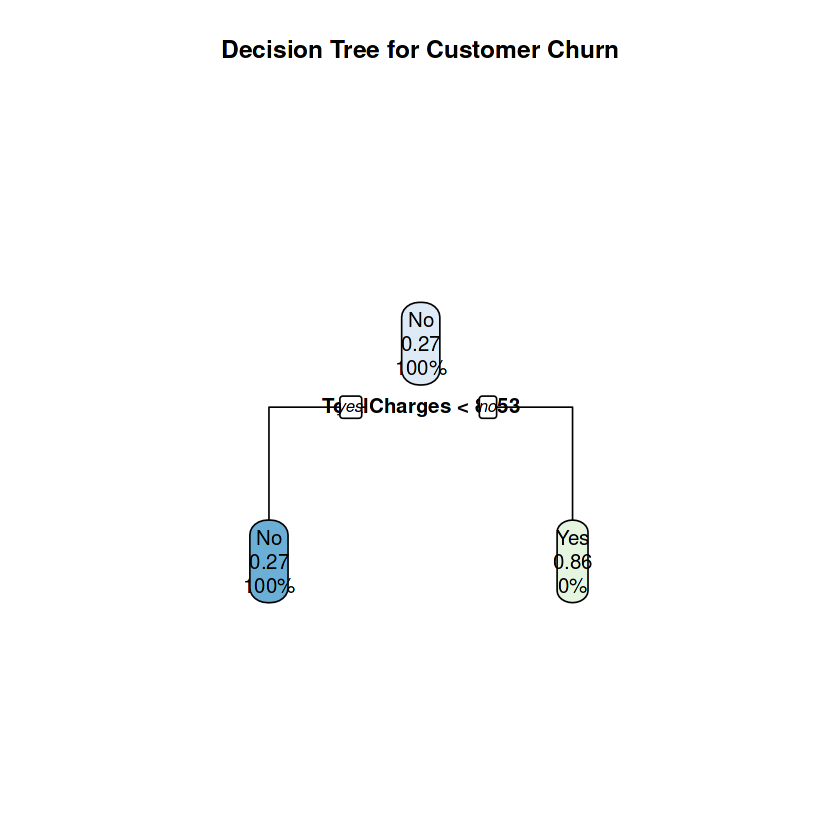

In [15]:
set.seed(123)

#70/30 Train Split of data
trainIndex <- createDataPartition(data$Churn, p = 0.7, list = FALSE)
train_data <- data[trainIndex, ]
test_data  <- data[-trainIndex, ]

# Fit Logistic Regression using specific columns
log_model <- glm(Churn ~ Tenure + MonthlyCharges + TotalCharges, 
                 data = train_data, 
                 family = "binomial")
summary(log_model)

# Fit Decision Tree using specific columns
# We add the 'control' argument to lower the cp threshold to 0.001
tree_model <- rpart(Churn ~ Tenure + MonthlyCharges + TotalCharges, 
                    data = train_data, 
                    method = "class",
                    control = rpart.control(cp = 0.001))

summary(tree_model)
# Plot the tree to visualize its complexity
rpart.plot(tree_model, main = "Decision Tree for Customer Churn")

Logistic Regression: 
This is a low-complexity, parametric model. It assumes a rigid, linear relationship between your variables. 

Trade-off: It is very easy to interpret (you can see the exact impact of a single dollar increase in monthly charges), but it struggles to capture complex, non-linear relationships.

Decision Tree: This is a higher-complexity, non-parametric model. 

Trade-off: It can easily capture non-linear patterns by making specific splits, but it is highly prone to overfitting the training data if you let the tree grow too deep.

7.

The bias-variance trade-off is the balance between a model being too simple (high bias) and too complex (high variance).

Bias is the error from making overly simplistic assumptions. Logistic regression typically has higher bias because it forces a linear fit onto data that might not be perfectly straight.

Variance is the error from a model being too sensitive to the training data. A deep Decision Tree has high variance because it effectively memorizes the training data, meaning it might perform poorly on new, unseen customer data.
The goal is to find the "sweet spot" in the middle, which is why we tune models and use ensembles like Random Forests.

8.

In [18]:
# Define 10-fold cross-validation
cv_control <- trainControl(method = "cv", number = 10)

# Train the model with 10-fold CV 
cv_log_model <- train(Churn ~ Tenure + MonthlyCharges + TotalCharges, 
                      data = train_data, 
                      method = "glm", 
                      family = "binomial",
                      trControl = cv_control)

# Make predictions on the unseen test set
cv_preds <- predict(cv_log_model, newdata = test_data)

# Generate Accuracy, Precision, Recall, and F1-Score
# mode = "everything" forces caret to output all of these at once
conf_matrix <- confusionMatrix(cv_preds, test_data$Churn, positive = "Yes", mode = "everything")

# Print the results
print(conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  2188  811
       Yes    0    0
                                          
               Accuracy : 0.7296          
                 95% CI : (0.7133, 0.7454)
    No Information Rate : 0.7296          
    P-Value [Acc > NIR] : 0.5095          
                                          
                  Kappa : 0               
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.0000          
            Specificity : 1.0000          
         Pos Pred Value :    NaN          
         Neg Pred Value : 0.7296          
              Precision :     NA          
                 Recall : 0.0000          
                     F1 :     NA          
             Prevalence : 0.2704          
         Detection Rate : 0.0000          
   Detection Prevalence : 0.0000          
      Balanced Accuracy 

9.

In [20]:
tune_grid <- expand.grid(.mtry = c(2, 4, 6))

rf_model <- train(Churn ~ Tenure + MonthlyCharges + TotalCharges, 
                  data = train_data, 
                  method = "rf", 
                  trControl = cv_control, 
                  tuneGrid = tune_grid,
                  ntree = 100) 

print(rf_model)

rf_preds <- predict(rf_model, newdata = test_data)
rf_conf_matrix <- confusionMatrix(rf_preds, test_data$Churn, positive = "Yes", mode = "everything")

print(rf_conf_matrix)

Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid mtry: reset to within valid range”
Warning message in randomForest.default(x, y, mtry = param$mtry, ...):
“invalid 

Random Forest 

7001 samples
   3 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 6301, 6302, 6300, 6300, 6301, 6302, ... 
Resampling results across tuning parameters:

  mtry  Accuracy   Kappa       
  2     0.6526241   0.003204305
  4     0.6509111  -0.011321385
  6     0.6541970  -0.002743222

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was mtry = 6.
Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1824  686
       Yes  364  125
                                         
               Accuracy : 0.6499         
                 95% CI : (0.6325, 0.667)
    No Information Rate : 0.7296         
    P-Value [Acc > NIR] : 1              
                                         
                  Kappa : -0.014         
                                         
 Mcnemar's Test P-Value : <2e-16         
                

# Unit 3

10.

In [21]:
log_model_unit3 <- glm(Churn ~ Tenure + MonthlyCharges + TotalCharges, 
                       data = train_data, 
                       family = "binomial")

summary(log_model_unit3)


Call:
glm(formula = Churn ~ Tenure + MonthlyCharges + TotalCharges, 
    family = "binomial", data = train_data)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -1.100e+00  1.415e-01  -7.775 7.57e-15 ***
Tenure          3.638e-03  3.364e-03   1.081    0.279    
MonthlyCharges  1.531e-03  1.846e-03   0.830    0.407    
TotalCharges   -5.173e-05  4.444e-05  -1.164    0.244    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 8176.2  on 7000  degrees of freedom
Residual deviance: 8174.7  on 6997  degrees of freedom
AIC: 8182.7

Number of Fisher Scoring iterations: 4


Coefficients: In logistic regression, these represent the change in the log-odds of churning. A negative coefficient (like you will likely see for Tenure) means that as tenure increases, the probability of churning goes down. A positive coefficient means the probability goes up.

P-values: Look at the Pr(>|z|) column. If the p-value is less than 0.05, that variable is a statistically significant predictor of churn.

11.

High-dimensional regression occurs when you have a massive number of predictors compared to the number of observations, or when predictors are highly correlated (multicollinearity).

Challenges: It leads to severe overfitting, makes the model computationally heavy, and inflates standard errors, making it hard to trust the coefficients.

Solutions: You can use dimensionality reduction (like PCA) to compress the data, or regularization (like Ridge/Lasso) to penalize complexity.

In [22]:
num_features <- train_data[, c("Tenure", "MonthlyCharges", "TotalCharges")]

pca_result <- prcomp(num_features, center = TRUE, scale. = TRUE)
summary(pca_result)

pca_result$rotation

Importance of components:
                          PC1    PC2    PC3
Standard deviation     1.3860 1.0127 0.2311
Proportion of Variance 0.6404 0.3418 0.0178
Cumulative Proportion  0.6404 0.9822 1.0000

,PC1,PC2,PC3
Tenure,-0.5782588,0.575600800,0.5781872
MonthlyCharges,-0.3985345,-0.817672124,0.4154306
TotalCharges,-0.7118898,-0.009798817,-0.7022229


12.

[1] "Optimal Ridge Lambda: 8.22625259120953"


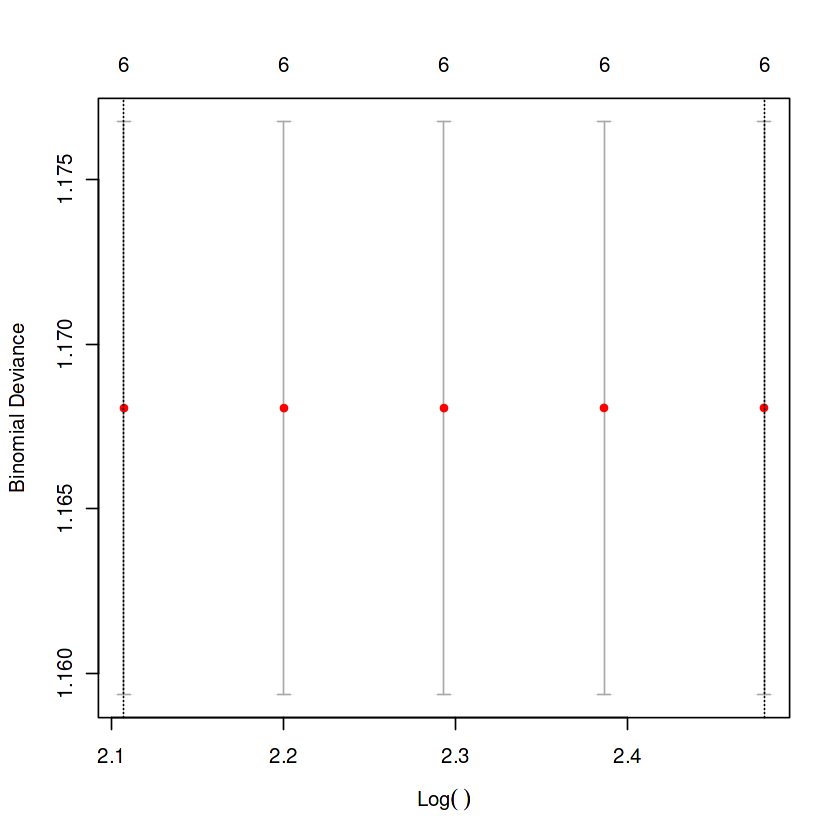

In [25]:
x_train <- model.matrix(Churn ~ Tenure + MonthlyCharges + TotalCharges + 
                        Gender + Partner + Dependents, data = train_data)[,-1]

y_train <- ifelse(train_data$Churn == "Yes", 1, 0)

set.seed(123)
cv_ridge <- cv.glmnet(x_train, y_train, alpha = 0, family = "binomial")

optimal_lambda_ridge <- cv_ridge$lambda.min
print(paste("Optimal Ridge Lambda:", optimal_lambda_ridge))

plot(cv_ridge)

13.

In [26]:
cv_lasso <- cv.glmnet(x_train, y_train, alpha = 1, family = "binomial")

optimal_lambda_lasso <- cv_lasso$lambda.min
print(paste("Optimal Lasso Lambda:", optimal_lambda_lasso))

lasso_final <- glmnet(x_train, y_train, alpha = 1, family = "binomial", lambda = optimal_lambda_lasso)
coef(lasso_final)

[1] "Optimal Lasso Lambda: 0.00622285840845149"


7 x 1 sparse Matrix of class "dgCMatrix"
                        s0
(Intercept)    -0.96298348
Tenure          .         
MonthlyCharges  .         
TotalCharges    .         
GenderMale     -0.05789558
PartnerYes      .         
DependentsYes   .         

This performs automatic feature selection. When you look at the coef(lasso_final) output, any variable with a . instead of a number has been entirely dropped from the model. This results in a cleaner, simpler, and more interpretable model that only keeps the strongest predictors of customer churn.